# Práctica 4. Procesamiento audio - Identificador de notas musicales

## Importación de librerías

In [4]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq


## Implementación

In [ ]:
class AudioProcessor:
    def __init__(self):
        pass

    def load_audio(self, filepath):
        sample_rate, audio_data = wavfile.read(filepath)
        if hasattr(audio_data, "shape") and len(audio_data.shape) > 1: # multicanal -> mono
            audio_data = np.mean(audio_data, axis=1) # promediado
        audio_data = audio_data.astype(float)
        maxabs = np.max(np.abs(audio_data)) if audio_data.size else 0.0
        if maxabs > 0:
            audio_data = audio_data / maxabs # normalización [-1.0, 1.0]
        return sample_rate, audio_data

    def extract_fundamental_frequencies(self, audio_data, sample_rate, 
                                        min_freq=30, max_freq=5000, num_peaks=5):
        n = len(audio_data)
        if n == 0:
            return []

        fft_values = fft(audio_data)
        fft_magnitude = np.abs(fft_values[:n//2])
        frequencies = fftfreq(n, 1/sample_rate)[:n//2]

        mask = (frequencies >= min_freq) & (frequencies <= max_freq)
        fft_magnitude = fft_magnitude[mask]
        frequencies = frequencies[mask]
        if frequencies.size == 0:
            return []

        threshold = np.max(fft_magnitude) * 0.02 # valores < threshold -> ruido

        peaks, properties = find_peaks(fft_magnitude,
                                       height=threshold,
                                       distance=15,
                                       prominence=threshold * 0.2)
        if len(peaks) == 0:
            return []

        peak_indices = np.argsort(properties['peak_heights'])[::-1]
        top_peaks = peaks[peak_indices[:num_peaks * 5]]

        detected_freqs = frequencies[top_peaks]
        detected_mags  = fft_magnitude[top_peaks]

        fundamental_candidates = []

        for freq, mag in zip(detected_freqs, detected_mags):
            is_fundamental = True
            subharmonic_penalty = 0.0

            # ¿freq es un armónico de una nota más grave?
            for other_freq in detected_freqs:
                if other_freq < freq * 0.8:
                    ratio = freq / other_freq
                    if abs(ratio - round(ratio)) < 0.1:
                        is_fundamental = False
                        subharmonic_penalty = ratio
                        break
            # ¿freq tiene armónicos?
            if is_fundamental:
                harmonic_score = 0
                for other_freq in detected_freqs:
                    if other_freq > freq * 1.85 and other_freq < freq * 8.5: # rango de armónicos
                        ratio = other_freq / freq
                        if abs(ratio - round(ratio)) < 0.1:
                            harmonic_score += 1

                # pesos: favorece las frecuencias bajas
                boost = 1.0
                if freq < 80: boost = 5.0
                elif freq < 120: boost = 4.0
                elif freq < 200: boost = 2.5
                elif freq < 300: boost = 1.5
                elif freq > 4000: boost = 0.3
                elif freq > 3000: boost = 0.6

                harmonic_boost = 1 + (harmonic_score * 0.8)
                adjusted_mag = mag * boost * harmonic_boost
                fundamental_candidates.append((freq, adjusted_mag, mag))
            else:
                # freq parece un armónico
                if freq < 100 and subharmonic_penalty > 1:
                    penalized_mag = mag * 0.1
                    fundamental_candidates.append((freq, penalized_mag, mag))

        # si no se han detectado fundamentales, se devuelven los picos más altos
        if not fundamental_candidates:
            for f, m in zip(detected_freqs[:num_peaks], detected_mags[:num_peaks]):
                fundamental_candidates.append((f, m, m))

        # ordenar por magnitud ajustada
        fundamental_candidates.sort(key=lambda x: x[1], reverse=True)
        final_candidates = fundamental_candidates[:num_peaks * 2]

        unique = {}
        for freq, adj_mag, orig_mag in final_candidates:
            if freq not in unique or adj_mag > unique[freq][1]:
                unique[freq] = (freq, adj_mag, orig_mag)

        result = [(f, orig) for (f, adj, orig) in sorted(unique.values(), key=lambda x: x[1], reverse=True)]
        return result[:num_peaks]

    def visualize_spectrum(self, audio_data, sample_rate, notes_detected):
        n = len(audio_data)
        fft_values = fft(audio_data * np.hanning(n))
        fft_magnitude = np.abs(fft_values[:n//2])
        frequencies = fftfreq(n, 1/sample_rate)[:n//2]

        plt.figure(figsize=(14, 6))

        # Señal temporal
        plt.subplot(1, 2, 1)
        time = np.linspace(0, len(audio_data)/sample_rate, len(audio_data))
        plt.plot(time, audio_data)
        plt.xlabel('Tiempo (s)')
        plt.ylabel('Amplitud')
        plt.title('Señal de Audio')
        plt.grid(True, alpha=0.3)

        # Espectro
        plt.subplot(1, 2, 2)
        mask = frequencies < 2000
        plt.plot(frequencies[mask], fft_magnitude[mask])

        for note, freq, mag in notes_detected[:5]:
            plt.axvline(x=freq, linestyle='--', alpha=0.7)
            plt.text(freq, mag, f'{note}\n{freq:.1f}Hz',
                     rotation=45, verticalalignment='bottom')

        plt.xlabel('Frecuencia (Hz)')
        plt.ylabel('Magnitud')
        plt.title('Espectro de Frecuencias')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


class NoteConverter:
    def __init__(self):
        self._note_frequencies = None
        self.build_table()

    def build_table(self):
        if self._note_frequencies is not None:
            return
        notes = ['Do', 'Do#', 'Re', 'Re#', 'Mi', 'Fa', 'Fa#', 'Sol', 'Sol#', 'La', 'La#', 'Si']
        freqs = {}
        for octave in range(0, 9):
            for i, note in enumerate(notes):
                freq = 440.0 * (2 ** ((octave * 12 + i - 57) / 12.0))
                freqs[f'{note}{octave}'] = freq
        self._note_frequencies = freqs

    def frequency_to_note(self, frequency, tolerance=2.0):
        if frequency <= 0:
            return None
        min_diff = float('inf')
        closest_note = None

        for note, fref in self._note_frequencies.items():
            diff = abs(frequency - fref)
            if fref <= 0:
                continue
            cents = 1200 * np.log2(frequency / fref)
            if abs(cents) < tolerance * 100:
                if diff < min_diff:
                    min_diff = diff
                    closest_note = note
        return closest_note


class SingleNoteIdentifier:
    def __init__(self):
        self.audio = AudioProcessor()
        self.converter = NoteConverter()

    def identify_note(self, filepath, visualize=False):
        sample_rate, audio_data = self.audio.load_audio(filepath)
        detected_freqs = self.audio.extract_fundamental_frequencies(audio_data, sample_rate)

        if not detected_freqs:
            return None, None, []

        notes_detected = []
        for freq, magnitude in detected_freqs:
            note = self.converter.frequency_to_note(freq)
            if note:
                notes_detected.append((note, freq, magnitude))

        if not notes_detected:
            return None, None, []

        main_note = notes_detected[0][0]
        main_freq = notes_detected[0][1]

        if visualize:
            self.audio.visualize_spectrum(audio_data, sample_rate, notes_detected)

        return main_note, main_freq, notes_detected

    def batch_process_directory(self, directory_path):
        results = []
        for root, dirs, files in os.walk(directory_path):
            for file in files:
                if not file.lower().endswith('.wav'):
                    continue
                filepath = os.path.join(root, file)
                try:
                    note, freq, all_notes = self.identify_note(filepath)
                    instrument = self.extract_instrument(filepath)
                    expected_note_full, expected_note, expected_octave = self.extract_expected_note(file)

                    note_name = note[:-1] if note else None
                    octave = note[-1] if note else None

                    note_correct = (note_name == expected_note) if (note_name and expected_note) else False
                    octave_correct = (octave == expected_octave) if (octave and expected_octave) else False
                    both_correct = note_correct and octave_correct

                    results.append({
                        'file': file,
                        'instrument': instrument,
                        'main_note': note,
                        'note_name': note_name,
                        'octave': octave,
                        'frequency': freq,
                        'all_notes': [n[0] for n in all_notes[:3]],
                        'expected_note_full': expected_note_full,
                        'expected_note': expected_note,
                        'expected_octave': expected_octave,
                        'note_correct': note_correct,
                        'octave_correct': octave_correct,
                        'both_correct': both_correct
                    })
                except Exception as e:
                    print(f"Error procesando {file}: {str(e)}")
        return results

    def extract_expected_note(self, filename):
        note_mapping = {
            'C': 'Do', 'C#': 'Do#', 'Db': 'Re♭',
            'D': 'Re', 'D#': 'Re#', 'Eb': 'Mi♭',
            'E': 'Mi',
            'F': 'Fa', 'F#': 'Fa#', 'Gb': 'Sol♭',
            'G': 'Sol', 'G#': 'Sol#', 'Ab': 'La♭',
            'A': 'La', 'A#': 'La#', 'Bb': 'Si♭',
            'B': 'Si'
        }
        pattern = r'([A-G][b#]?)(\d)'
        match = re.search(pattern, filename)
        if match:
            note_eng = match.group(1)
            octave = match.group(2)
            note_esp = note_mapping.get(note_eng, note_eng)
            return f"{note_esp}{octave}", note_esp, octave
        return None, None, None

    def extract_instrument(self, filename):
        filename_only = os.path.basename(filename).lower()
        inst_mapping = {
            'btb': 'Tuba Bajo',
            'hn': 'Trompa',
            'tbn': 'Trombón',
            'tpc': 'Trompeta en Do',
            'acc': 'Acordeón',
            'cb': 'Contrabajo',
            'vn': 'Violín',
            'va': 'Viola',
            'vc': 'Violonchelo',
            'bn': 'Fagot',
            'clbb': 'Clarinete en Sib',
            'fl': 'Flauta',
            'ob': 'Oboe',
            'asax': 'Saxofón alto'
        }
        for code, instrument_name in inst_mapping.items():
            if filename_only.startswith(code):
                return instrument_name
        return 'Desconocido'

    def evaluate_accuracy(self, results):
        total = len(results)
        identified = sum(1 for r in results if r['main_note'] is not None)

        with_expected = [r for r in results if r.get('expected_note_full')]
        total_with_expected = len(with_expected)

        if total_with_expected > 0:
            note_correct = sum(1 for r in with_expected if r.get('note_correct', False))
            octave_correct = sum(1 for r in with_expected if r.get('octave_correct', False))
            both_correct = sum(1 for r in with_expected if r.get('both_correct', False))

            print(f"\n=== ESTADÍSTICAS DE PRECISIÓN ===")
            print(f"Total de archivos procesados: {total}")
            print(f"Archivos con nota esperada identificable: {total_with_expected}")
            print(f"Notas detectadas: {identified}/{total} ({(identified/total)*100:.2f}%)")
            print(f"\n--- PRECISIÓN ---")
            print(f"Nota correcta (sin octava): {note_correct}/{total_with_expected} ({(note_correct/total_with_expected)*100:.2f}%)")
            print(f"Octava correcta: {octave_correct}/{total_with_expected} ({(octave_correct/total_with_expected)*100:.2f}%)")
            print(f"Nota + Octava correctas: {both_correct}/{total_with_expected} ({(both_correct/total_with_expected)*100:.2f}%)")

            note_errors = [r for r in with_expected if not r.get('note_correct', False)]
            octave_errors = [r for r in with_expected if not r.get('octave_correct', False)]

            if note_errors:
                print(f"\n--- ERRORES DE NOTA ({len(note_errors)}) ---")
                for r in note_errors[:10]:
                    print(f"  {r['file']}: Esperada={r['expected_note']} | Detectada={r['note_name']}")

            if octave_errors:
                print(f"\n--- ERRORES DE OCTAVA ({len(octave_errors)}) ---")
                for r in octave_errors[:15]:
                    print(f"  {r['file']}: Esperada={r['expected_octave']} | Detectada={r['octave']}")
        else:
            print(f"\n=== ESTADÍSTICAS ===")
            print(f"Total de archivos procesados: {total}")
            print(f"Notas identificadas: {identified}")
            print(f"Tasa de detección: {(identified/total)*100:.2f}%")
            print(f"\n(No se pudo extraer nota esperada de los nombres de archivo)")

        instrument_stats = {}
        for r in results:
            inst = r['instrument']
            if inst not in instrument_stats:
                instrument_stats[inst] = {
                    'total': 0, 
                    'identified': 0,
                    'note_correct': 0,
                    'octave_correct': 0,
                    'both_correct': 0
                }
            instrument_stats[inst]['total'] += 1
            if r['main_note']:
                instrument_stats[inst]['identified'] += 1
            if r.get('note_correct'):
                instrument_stats[inst]['note_correct'] += 1
            if r.get('octave_correct'):
                instrument_stats[inst]['octave_correct'] += 1
            if r.get('both_correct'):
                instrument_stats[inst]['both_correct'] += 1

        print(f"\n=== PRECISIÓN POR INSTRUMENTO ===")
        for inst, stats in sorted(instrument_stats.items()):
            det_rate = (stats['identified']/stats['total'])*100 if stats['total'] > 0 else 0
            note_rate = (stats['note_correct']/stats['total'])*100 if stats['total'] > 0 else 0
            oct_rate = (stats['octave_correct']/stats['total'])*100 if stats['total'] > 0 else 0
            both_rate = (stats['both_correct']/stats['total'])*100 if stats['total'] > 0 else 0

            print(f"\n{inst}:")
            print(f"  Detectadas: {stats['identified']}/{stats['total']} ({det_rate:.1f}%)")
            print(f"  Nota correcta: {stats['note_correct']}/{stats['total']} ({note_rate:.1f}%)")
            print(f"  Octava correcta: {stats['octave_correct']}/{stats['total']} ({oct_rate:.1f}%)")
            print(f"  Ambas correctas: {stats['both_correct']}/{stats['total']} ({both_rate:.1f}%)")


=== IDENTIFICADOR DE NOTAS MUSICALES ===

Analizando: data/E1/TinySOL/Winds/Oboe/ordinario/Ob-ord-A4-ff-N-N.wav



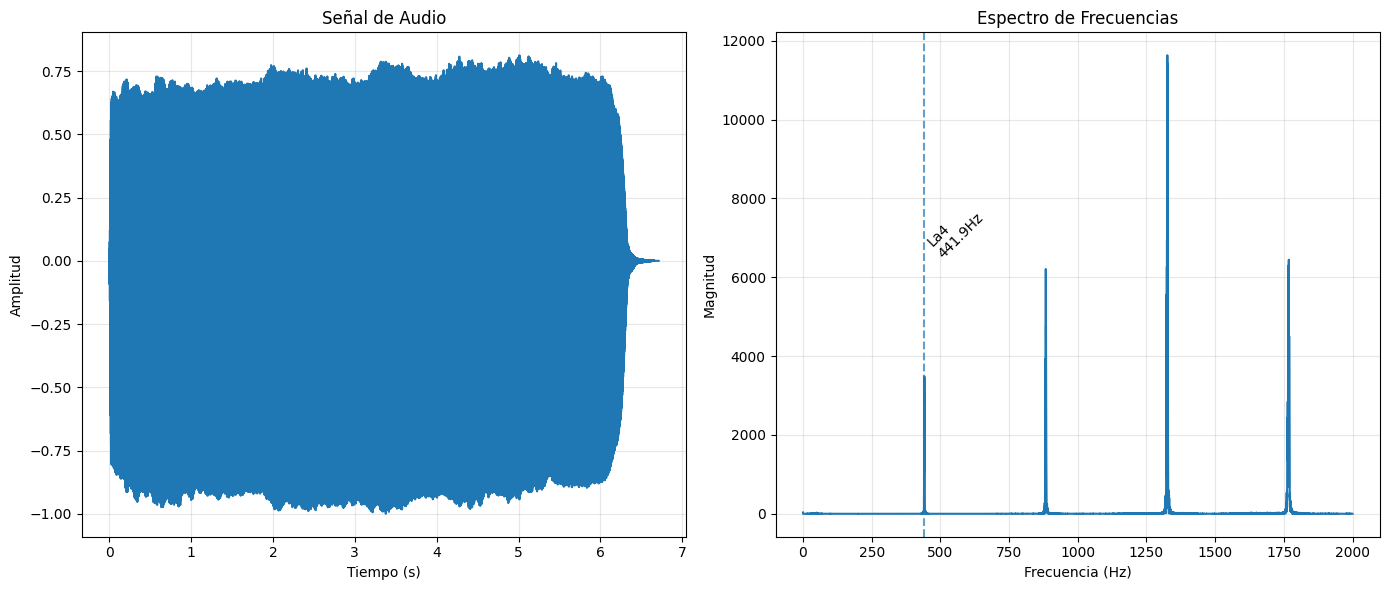

Instrumento: Oboe

--- NOTA ESPERADA ---
Nota completa: La4
Nota: La
Octava: 4

--- NOTA DETECTADA ---
Nota completa: La4
Nota: La
Octava: 4
Frecuencia fundamental: 441.93 Hz

--- VERIFICACIÓN ---
Nota correcta: True
Octava correcta: True
Ambas correctas: True

--- OTRAS FRECUENCIAS DETECTADAS ---
1. La4: 441.93 Hz (magnitud: 6417)


In [10]:
identifier = SingleNoteIdentifier()

print("=== IDENTIFICADOR DE NOTAS MUSICALES ===\n")
audio_file = "data/E1/TinySOL/Winds/Oboe/ordinario/Ob-ord-A4-ff-N-N.wav"

if os.path.exists(audio_file):
    print(f"Analizando: {audio_file}\n")

    filename = os.path.basename(audio_file)
    expected_note_full, expected_note, expected_octave = identifier.extract_expected_note(filename)
    instrument = identifier.extract_instrument(audio_file)

    note, freq, all_notes = identifier.identify_note(audio_file, visualize=True)

    print(f"Instrumento: {instrument}\n")
    if expected_note_full:
        print(f"--- NOTA ESPERADA ---")
        print(f"Nota completa: {expected_note_full}")
        print(f"Nota: {expected_note}")
        print(f"Octava: {expected_octave}\n")

    if note:
        note_name = note[:-1]
        octave = note[-1]
        print(f"--- NOTA DETECTADA ---")
        print(f"Nota completa: {note}")
        print(f"Nota: {note_name}")
        print(f"Octava: {octave}")
        print(f"Frecuencia fundamental: {freq:.2f} Hz\n")

        if expected_note_full:
            note_correct = (note_name == expected_note)
            octave_correct = (octave == expected_octave)
            both_correct = note_correct and octave_correct

            print(f"--- VERIFICACIÓN ---")
            print(f"Nota correcta: {note_correct}")
            print(f"Octava correcta: {octave_correct}")
            print(f"Ambas correctas: {both_correct}\n")

            if not octave_correct:
                diff = int(octave) - int(expected_octave)
                print(f"Diferencia de octava: {abs(diff)} octava(s)\n")

        print(f"--- OTRAS FRECUENCIAS DETECTADAS ---")
        for i, (n, f, m) in enumerate(all_notes[:5], 1):
            print(f"{i}. {n}: {f:.2f} Hz (magnitud: {m:.0f})")
else:
    print(f"El archivo no existe: {audio_file}")


In [11]:
note_identifier = SingleNoteIdentifier()
results = note_identifier.batch_process_directory("data/E1/TinySOL")
note_identifier.evaluate_accuracy(results)



=== ESTADÍSTICAS DE PRECISIÓN ===
Total de archivos procesados: 1197
Archivos con nota esperada identificable: 1197
Notas detectadas: 1197/1197 (100.00%)

--- PRECISIÓN ---
Nota correcta (sin octava): 1187/1197 (99.16%)
Octava correcta: 1179/1197 (98.50%)
Nota + Octava correctas: 1179/1197 (98.50%)

--- ERRORES DE NOTA (10) ---
  Tbn-ord-A#1-ff-N-T14d.wav: Esperada=La# | Detectada=Fa
  Acc-ord-A#7-pp-N-N.wav: Esperada=La# | Detectada=Sol
  Acc-ord-A4-pp-alt1-N.wav: Esperada=La | Detectada=Sol
  Acc-ord-A4-pp-N-N.wav: Esperada=La | Detectada=Sol
  Acc-ord-B3-pp-N-N.wav: Esperada=Si | Detectada=Sol
  Acc-ord-C#6-pp-N-N.wav: Esperada=Do# | Detectada=La#
  Acc-ord-D3-pp-N-N.wav: Esperada=Re | Detectada=Sol
  Acc-ord-D5-pp-alt1-N.wav: Esperada=Re | Detectada=Sol
  Acc-ord-E6-pp-alt2-N.wav: Esperada=Mi | Detectada=Sol
  Acc-ord-F#5-pp-alt2-N.wav: Esperada=Fa# | Detectada=Sol

--- ERRORES DE OCTAVA (18) ---
  Tbn-ord-A#1-ff-N-T14d.wav: Esperada=1 | Detectada=3
  Acc-ord-A#7-pp-N-N.wav: Esper